<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/6_modulo/6_modulo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/6_modulo/6_modulo.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

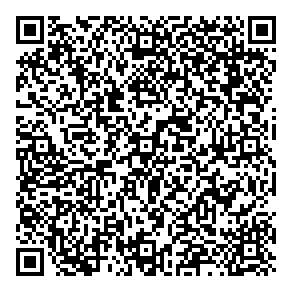

In [1]:
# QR para el cuaderno de clase que permite lectura activa y experimental
import qrcode
from PIL import Image
import os

# URL del notebook en GitHub
url = "https://colab.research.google.com/github/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/6_modulo/6_modulo.ipynb"

# Configuración del QR
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=4,
    border=4,
)

# Añadir datos al QR
qr.add_data(url)
qr.make(fit=True)

# Crear imagen del QR
img = qr.make_image(fill_color="black", back_color="white")

# Guardar imagen
output_path = "github_notebook_qr.png"
img.save(output_path)

# Mostrar imagen generada (solo si se ejecuta en Jupyter Notebook/Lab)
try:
    display(Image.open(output_path))
except:
    print(f"Código QR generado y guardado en: {os.path.abspath(output_path)}")
    print("Ábralo con cualquier visor de imágenes o escanéelo con su móvil.")
    img.show()  # Abre la imagen en el visor predeterminado



### [Video de apoyo a la lectura del módulo 6 desde el texto de Clara Elena Mejía Laverde](https://www.youtube.com/watch?v=iOLg7G0P2nc)

### [Video de apoyo a la lectura y experimentación con la pizarra](https://www.youtube.com/watch?v=GoEGAmwxJYs&list=PLbk60veMSVKurxtWwlDeSnxO2H0goZ4--&index=2&t=10s)

### [Video de apoyo a la lectura interactiva y experimental del módulo 6 desde el cuaderno Jupyter y con lenguaje Python]()

### [Vínculo al programa del curso: Linear_Algebra ](https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/0_programa_cronograma_curso/1_programa_linear_algebra/1_programa_linear_algebra.md)

Código del curso: 5009318  

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/linear_algebra/blob/main/images/geo_vectorial_ultima_clase_2025-11-04.jpg?raw=true' width = 300> 



In [3]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/linear_algebra.xlsx'
df = pd.read_excel(path)
df.index = range(1, len(df) + 1)
df.head(11) 


,Cédula,Nombre,Email
1,1007676529,ARENAS HERAZO GABRIEL ENRIQUE,gabriel.arenas@udea.edu.co
2,1038547924,ARROYAVE ECHAVARRIA LAURA SOFIA,sofia.arroyave@udea.edu.co
3,1007528664,AYALA MENDOZA MARISOL YACIRA,marisol.ayala@udea.edu.co
4,1007676170,CANTILLO ENSUCHO DANIEL,daniel.cantillo@udea.edu.co
5,1038104030,IBAÑEZ MORENO FRANCISCO LUIS,francisco.ibanez@udea.edu.co
6,1066570075,MONTERROSA SOTO ABRIL,a.monterrosa@udea.edu.co
7,1038099623,NORIEGA JIMENEZ GABRIELA,gabriela.noriega@udea.edu.co
8,1129805618,PEREZ THERAN ERLINDA,erlinda.perez@udea.edu.co
9,1038101968,QUINONEZ CERVANTES MARIANA,mariana.quinonezc@udea.edu.co
10,1007318378,RAMOS PEREZ YANINE,y.ramos@udea.edu.co


# Módulo 6. Subespacios asociado a una matriz

### [Vínculo para obtener el texto guía gratis]()

$$
A = \begin{bmatrix} 
3&0&-1\\ 
3&0&-1 \\ 
4&0&5
\end{bmatrix}
$$

Para esta matriz

$$
A=\begin{bmatrix}
3&0&-1\\ 
3&0&-1\\ 
4&0&5
\end{bmatrix}
$$



* **Espacio fila**: generado por las filas linealmente independientes 
  $r_1=(3,0,-1)$, $r_3=(4,0,5)$  → plano en $\mathbb{R}^3$.
* **Espacio columna**: generado por las columnas independientes 
  $c_1=(3,3,4)$, $c_3=(-1,-1,5)$ → otro plano en $\mathbb{R}^3$.
* **Espacio nulo**: soluciones de $Ax=0$  
  
  $\Rightarrow x=0, z=0, y$ libre → recta generada por $(0,1,0)$ (eje $y$).



El siguiente script en **Plotly** dibuja en un mismo sistema 3D:

* ejes coordenados resaltados,
* plano del espacio fila,
* plano del espacio columna,
* recta del espacio nulo.


In [1]:
import numpy as np
import plotly.graph_objects as go

# =========================
# Bases de los subespacios
# =========================
r1 = np.array([3, 0, -1])
r3 = np.array([4, 0, 5])

c1 = np.array([3, 3, 4])
c3 = np.array([-1, -1, 5])

n1 = np.array([0, 1, 0])  # base del espacio nulo

# =========================
# Parámetros para generar planos
# =========================
s = np.linspace(-2, 2, 30)
t = np.linspace(-2, 2, 30)
S, T = np.meshgrid(s, t)

# Plano del espacio fila: span{r1, r3}
X_row = r1[0]*S + r3[0]*T
Y_row = r1[1]*S + r3[1]*T
Z_row = r1[2]*S + r3[2]*T

# Plano del espacio columna: span{c1, c3}
X_col = c1[0]*S + c3[0]*T
Y_col = c1[1]*S + c3[1]*T
Z_col = c1[2]*S + c3[2]*T

# Recta del espacio nulo
u = np.linspace(-5, 5, 100)
X_null = n1[0]*u
Y_null = n1[1]*u
Z_null = n1[2]*u

# =========================
# Ejes coordenados resaltados
# =========================
axis_len = 6

axis_x = go.Scatter3d(
    x=[-axis_len, axis_len], y=[0,0], z=[0,0],
    mode='lines',
    line=dict(width=6, color='black'),
    name='Eje X'
)

axis_y = go.Scatter3d(
    x=[0,0], y=[-axis_len, axis_len], z=[0,0],
    mode='lines',
    line=dict(width=6, color='black'),
    name='Eje Y'
)

axis_z = go.Scatter3d(
    x=[0,0], y=[0,0], z=[-axis_len, axis_len],
    mode='lines',
    line=dict(width=6, color='black'),
    name='Eje Z'
)

# =========================
# Figura
# =========================
fig = go.Figure()

# Espacio fila (plano azul)
fig.add_surface(
    x=X_row, y=Y_row, z=Z_row,
    opacity=0.6,
    colorscale=[[0, 'blue'], [1, 'blue']],
    showscale=False
)

# Entrada para la leyenda del espacio fila
fig.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='blue', width=6),
    name='Espacio fila'
))

# Espacio columna (plano verde)
fig.add_surface(
    x=X_col, y=Y_col, z=Z_col,
    opacity=0.6,
    colorscale=[[0, 'green'], [1, 'green']],
    showscale=False
)

# Entrada para la leyenda del espacio columna
fig.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='green', width=6),
    name='Espacio columna'
))

# Espacio nulo (rojo y más grueso)
fig.add_trace(go.Scatter3d(
    x=X_null, y=Y_null, z=Z_null,
    mode='lines',
    line=dict(color='red', width=10),
    name='Espacio nulo'
))

# Añadir ejes
fig.add_trace(axis_x)
fig.add_trace(axis_y)
fig.add_trace(axis_z)

# Layout
fig.update_layout(
    title="Espacio fila, espacio columna y espacio nulo de la matriz A",
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='cube'
    ),
    legend=dict(
        x=0.02,
        y=0.98
    )
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\espacios_fila_columna_nulo.png")


Este gráfico permite ver simultáneamente:

* dos planos distintos (fila y columna),
* la recta del espacio nulo (alineada con el eje $y$),
* y los ejes coordenados para referencia geométrica.


# Contenidos del módulo  



1. Espacios nulo, renglón y columna de una matriz $A$. 

 
2. Propiedades.  


3. Relaciones con el espacio nulo o núcleo de una matriz $A$.

  
4. Relaciones con el rango de una matriz $A$.  

# Objetivos del módulo  

1. Determinar los subespacios asociados con una matriz.


2. Establecer las diferentes relaciones que existen entre estos subespacios.


3. Utilizar estos subespacios para determinar bases de subespacios generados por un conjunto de vectores.


4. Utilizar el rango de una matriz para determinar cuándo un sistema de ecuaciones lineales no homogéneo tiene solución.

# Preguntas básicas


1. ¿Cuáles son los subespacios asociados con $A$?


En las siguientes preguntas, la matriz $B$ es la matriz escalonada equivalente por renglones a $A$.


2. ¿Cómo son los espacios nulo y renglón de las matrices $A$ y $B$?


3. ¿Qué relación existe entre los espacios renglón y columna de $A$?


4. ¿Cómo se relacionan los espacios nulo y renglón de $A$?


5. ¿Qué es el rango de una matriz?


6. ¿Cómo se relacionan los rangos de $A$ y $B$?


7. ¿Qué condición debe cumplir el término $b$ en la ecuación matricial $Ax = b$ para que el sistema tenga solución?


8. ¿Cómo se relacionan el rango y la nulidad de $A$ con el número de columnas de $A$?

# Introducción


En esta sección se darán técnicas que nos permiten determinar una base para un espacio vectorial que surge como generado por un conjunto de vectores que no son linealmente independientes. 

Además, asignaremos a cada matriz $A$ un número que nos informa acerca del número de renglones o columnas LI de $A$.

Este número será el rango de la matriz.

# 6.1 Espacio nulo, reglón y columna de una matriz A  

## Definición 1  



Sea $A$ una matriz de $m \times n$. El conjunto  

$$
N_{A} = \{\mathbf{x} \in \mathbb{R}^{n}: A\mathbf{x} = \mathbf{0}_{m} \}
$$  

se llama *espacio nulo de $A$* o *núcleo de $A$* y se denota por $N_{A}$. 

En el ejemplo 9 del módulo 5 mostramos que este conjunto es un subespacio de $\mathbb{R}^{n}$.  



A la dimensión de $N_{A}$ se le llama nulidad de $A$ y se denota $\nu(A)$.

# Ejemplo 1   
 
### [Video de apoyo a la presentación de este ejemplo en pizarra](https://www.youtube.com/watch?v=GoEGAmwxJYs)  


Sea $A = \begin{bmatrix} 1 & -1 & 2 \\ 3 & 1 & 0 \end{bmatrix}$, determine el espacio nulo de $A$. 


## Solución  



La matriz $A$ es la matriz de coeficientes del sistema homogéneo $A\mathbf{x} = \mathbf{0}$. 

Hacemos operaciones elementales de renglón para hallar las soluciones de este sistema.  


$$
A=\begin{bmatrix}
1 & -1 & 2\\
3 & 1 & 0
\end{bmatrix}
$$



$$
\begin{aligned}
\begin{bmatrix}
1 & -1 & 2\\
3 & 1 & 0
\end{bmatrix}
&\xrightarrow{\,F_2 \leftarrow F_2 - 3F_1\,}
\begin{bmatrix}
1 & -1 & 2\\
0 & 4 & -6
\end{bmatrix}
\\[6pt]
&\xrightarrow{\,F_2 \leftarrow \tfrac{1}{4}F_2\,}
\begin{bmatrix}
1 & -1 & 2\\
0 & 1 & -\tfrac{3}{2}
\end{bmatrix}
\\[6pt]
&\xrightarrow{\,F_1 \leftarrow F_1 + F_2\,}
\begin{bmatrix}
1 & 0 & \tfrac{1}{2}\\
0 & 1 & -\tfrac{3}{2}
\end{bmatrix}
\end{aligned}
$$


Así obtenemos la matriz reducida 

$$
\begin{bmatrix} 1 & 0 & 1/2 \\ 0 & 1 & -3/2 \end{bmatrix}
$$  



El sistema equivalente es 

$$
x_{1} + \frac{1}{2}x_{3} = 0
$$  

$$
x_{2} + \frac{-3}{2}x_{3} = 0
$$

de donde obtenemos las ecuaciones paramétricas:   

$$
x_{1} = -\frac{1}{2}x_{3}
$$  

$$
x_{2} = \frac{3}{2}x_{3}
$$

$$
x_{3} = x_{3}
$$ 

A $x_{3}$ la llamamos parámetro o variable libre. 

$$
N_{A} = \begin{pmatrix}-1/2 \\ 3/2 \\ 1 \end{pmatrix}
$$

por tanto, $\nu(A) = 1$. 

### [Video de apoyo a la presentación de este ejemplo en pizarra](https://www.youtube.com/watch?v=GoEGAmwxJYs)

In [2]:
# presentación del espacio nulo de la matriz A del ejemplo anterior  

import numpy as np
import plotly.graph_objects as go

# =========================
# Vector generador
# =========================
v = np.array([-1/2, 3/2, 1])

# Parámetro para la recta: t*v
t = np.linspace(-6, 6, 100)
x = t * v[0]
y = t * v[1]
z = t * v[2]

# =========================
# Crear figura
# =========================
fig = go.Figure()

# Recta generada por el vector
fig.add_trace(go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines',
    name='Recta generada por v',
    line=dict(width=6)
))

# Vector generador desde el origen
fig.add_trace(go.Scatter3d(
    x=[0, v[0]],
    y=[0, v[1]],
    z=[0, v[2]],
    mode='lines+markers',
    name='Vector generador',
    line=dict(width=8),
    marker=dict(size=4)
))

# =========================
# Ejes coordenados
# =========================
L = 6

# Eje X
fig.add_trace(go.Scatter3d(
    x=[-L, L], y=[0, 0], z=[0, 0],
    mode='lines',
    name='Eje X',
    line=dict(width=4, dash='dash')
))

# Eje Y
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[-L, L], z=[0, 0],
    mode='lines',
    name='Eje Y',
    line=dict(width=4, dash='dash')
))

# Eje Z
fig.add_trace(go.Scatter3d(
    x=[0, 0], y=[0, 0], z=[-L, L],
    mode='lines',
    name='Eje Z',
    line=dict(width=4, dash='dash')
))

# =========================
# Diseño
# =========================
fig.update_layout(
    title="Recta generada por el vector v = (-1/2, 3/2, 1)",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode='cube'
    ),
    showlegend=True
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\espacio_nulo_A.png")


# Definición 2  



Sea 
$$
A_{mn} = \begin{bmatrix} 
a_{11}&a_{12}&\cdots&a_{1n}\\  
a_{21}&a_{22}&\cdots&a_{2n}\\   
\vdots& \vdots& \cdots & \vdots \\  
a_{m1}&a_{m2}&\cdots&a_{mn}\\  
 \end{bmatrix}
$$



1.  El espacio generado por los renglones de $A$    

$$
r_{1} = (a_{11}, a_{12}, \cdots, a_{1n}), \quad r_{2} = (a_{21}, a_{22}, \cdots, a_{2n}), \ldots \quad, r_{m} = (a_{m1}, a_{m2}, \cdots, a_{mn})
$$  
   
es un subespacio de $\mathbb{R}^{n}$ llamado espacio renglón de $A$ y se denota $R_{A}$.  



2. El espacio generado por las columnas de $A$  

   $$
   c_{1} = \begin{bmatrix}a_{11}\\a_{21}\\ \vdots \\ a_{m1} \end{bmatrix}, \quad c_{2} = \begin{bmatrix}a_{12}\\a_{22}\\\vdots\\a_{m2} \end{bmatrix}, \quad \cdots \quad c_{n} = \begin{bmatrix}a_{1n} \\ a_{2n} \\ \vdots \\ a_{mn} \end{bmatrix}, \quad
   $$    

   es un subespacio de $\mathbb{R}^{m}$ llamado espacio columna de $A$ y se denota $C_{A}$. 
 

# 6.2 Propiedades  

# Teorema 1  

Si $A$ y $B$ son matrices $m \times n$ equivalentes por renglones, entonces los espacios generados por los renglones de $A$ y de $B$ son iguales.

## Demostración  



Si $A$ y $B$ son equivalentes por renglones, entonces $B$ se obtiene de $A$ por operaciones elementales de renglón.

Es claro que la operación de intercambio de renglones no afecta el espacio renglón. 

Las otras operaciones $cR_{i}$ y $R_{j} + cR_{i}$ son combinaciones lineales entre los renglones de $A$, las cuales pertenecen al espacio renglón $A$.  


Por tanto, el espacio generado por los renglones de $B$ está contenido en el espacio generado por los renglones de $A$, $R_{B} \subset R_{A}$.


De forma análoga se ve que $R_{A} \subset R_{B}$. 

En consecuencia, $R_{A} = R_{B}$. 


Este resultado nos permite determinar una base para un espacio vectorial generado por un conjunto de vectores dado de $\mathbb{R}^{n}$.

# Ejemplo 2  

Sea 

$$
S = \left\{ \begin{pmatrix} 2\\ -3\\ 4\\ 1\\ 2\end{pmatrix}, \begin{pmatrix} 4\\ -6\\ 5\\ 3\\-4 \end{pmatrix}, \begin{pmatrix}-10\\15\\-14\\3\\7\end{pmatrix}, \begin{pmatrix}-8\\12\\-10\\4\\9\end{pmatrix} \right\} 
$$  

Determine una base para $gen\ S$.

## Solución  

Tomamos los vectores de $S$ como renglones de una matriz $A$ y por medio de operaciones elementales obtenemos una matriz equivalente $B$ en forma escalonada. 

Los renglones no nulos de $B$ serán LI y formarán una base para  $R_{B}$ que es el mismo $R_{A}$.
Estos vectores tomados como columnas serán una base para $gen\ S$.

$$
S = \left\{ 
\begin{pmatrix} 2\\ -3\\ 4\\ 1\\ 2\end{pmatrix}, 
\begin{pmatrix} 4\\ -6\\ 5\\ 3\\ -4 \end{pmatrix}, 
\begin{pmatrix} -10\\ 15\\ -14\\ 3\\ 7\end{pmatrix}, 
\begin{pmatrix} -8\\ 12\\ -10\\ 4\\ 9\end{pmatrix} 
\right\}
$$

Ponemos estos vectores como filas de una matriz $A$:

$$
A=
\begin{bmatrix}
2 & -3 & 4 & 1 & 2\\
4 & -6 & 5 & 3 & -4\\
-10 & 15 & -14 & 3 & 7\\
-8 & 12 & -10 & 4 & 9
\end{bmatrix}
$$



$$
\begin{aligned}
A
&=
\begin{bmatrix}
2 & -3 & 4 & 1 & 2\\
4 & -6 & 5 & 3 & -4\\
-10 & 15 & -14 & 3 & 7\\
-8 & 12 & -10 & 4 & 9
\end{bmatrix}
\\[6pt]
&\xrightarrow{\,F_1 \leftarrow \tfrac12 F_1\,}
\begin{bmatrix}
1 & -\tfrac32 & 2 & \tfrac12 & 1\\
4 & -6 & 5 & 3 & -4\\
-10 & 15 & -14 & 3 & 7\\
-8 & 12 & -10 & 4 & 9
\end{bmatrix}
\\[8pt]
&\xrightarrow{\substack{
F_2 \leftarrow F_2-4F_1\\
F_3 \leftarrow F_3+10F_1\\
F_4 \leftarrow F_4+8F_1}}
\begin{bmatrix}
1 & -\tfrac32 & 2 & \tfrac12 & 1\\
0 & 0 & -3 & 1 & -8\\
0 & 0 & 6 & 8 & 17\\
0 & 0 & 6 & 8 & 17
\end{bmatrix}
\\[10pt]
&\xrightarrow{\,F_2 \leftarrow -\tfrac13 F_2\,}
\begin{bmatrix}
1 & -\tfrac32 & 2 & \tfrac12 & 1\\
0 & 0 & 1 & -\tfrac13 & \tfrac83\\
0 & 0 & 6 & 8 & 17\\
0 & 0 & 6 & 8 & 17
\end{bmatrix}
\\[8pt]
&\xrightarrow{\substack{
F_3 \leftarrow F_3-6F_2\\
F_4 \leftarrow F_4-6F_2}}
\begin{bmatrix}
1 & -\tfrac32 & 2 & \tfrac12 & 1\\
0 & 0 & 1 & -\tfrac13 & \tfrac83\\
0 & 0 & 0 & 10 & 1\\
0 & 0 & 0 & 10 & 1
\end{bmatrix}
\\[10pt]
&\xrightarrow{\,F_3 \leftarrow \tfrac1{10}F_3\,}
\begin{bmatrix}
1 & -\tfrac32 & 2 & \tfrac12 & 1\\
0 & 0 & 1 & -\tfrac13 & \tfrac83\\
0 & 0 & 0 & 1 & \tfrac1{10}\\
0 & 0 & 0 & 10 & 1
\end{bmatrix}
\\[8pt]
&\xrightarrow{\,F_4 \leftarrow F_4-10F_3\,}
\begin{bmatrix}
1 & -\tfrac32 & 2 & \tfrac12 & 1\\
0 & 0 & 1 & -\tfrac13 & \tfrac83\\
0 & 0 & 0 & 1 & \tfrac1{10}\\
0 & 0 & 0 & 0 & 0
\end{bmatrix}
\\[10pt]
&\xrightarrow{\substack{
F_2 \leftarrow F_2+\tfrac13 F_3\\
F_1 \leftarrow F_1-\tfrac12 F_3}}
\begin{bmatrix}
1 & -\tfrac32 & 2 & 0 & \tfrac{19}{20}\\
0 & 0 & 1 & 0 & \tfrac{27}{10}\\
0 & 0 & 0 & 1 & \tfrac1{10}\\
0 & 0 & 0 & 0 & 0
\end{bmatrix}
\\[10pt]
&\xrightarrow{\,F_1 \leftarrow F_1-2F_2\,}
\begin{bmatrix}
1 & -\tfrac32 & 0 & 0 & -\tfrac{89}{20}\\
0 & 0 & 1 & 0 & \tfrac{27}{10}\\
0 & 0 & 0 & 1 & \tfrac1{10}\\
0 & 0 & 0 & 0 & 0
\end{bmatrix}
\end{aligned}
$$



La última matriz es la forma escalonada reducida por filas (RREF) de $A$.


$$
\text{Base para } gen\  S = \left\{ \begin{pmatrix} 1\\-3/2\\0\\0\\-89/20\end{pmatrix}, \begin{pmatrix}0\\0\\1\\0\\27/10\end{pmatrix}, \begin{pmatrix}0\\0\\0\\1\\1/10\end{pmatrix}\right\}. 
$$

# Observación  

Si $B$ es una matriz escalonada, entonces $dim\ R_{B}$ es igual al número de pivotes de $B$.

# Teorema 2  

Sea $B$ una matriz $m \times n$ en la forma escalonada por renglones. Las columnas de $B$ que contienen los pivotes forman una base para $C_{B}$ y, por tanto, $dim\ C_{B}$ es igual al número de pivotes de $B$.

## Demostración


Las columnas de $B$ que contiene $n$ pivotes son LI porque sus entradas distintas de cero están en forma escalonada (en el ejemplo 2 las columnas 1, 3 y 4 son LI).


Veamos que estas columnas generan $C_{B}$.

Sea $\rho$ el número de pivotes de $B$. 

Los primeros $\rho$ renglones de $B$ son diferentes de cero y los últimos $m – rho$ son todos cero.


Sea $\mathbf{b} \in C_{B}$, $\mathbf{b}$ es combinación lineal de las columnas de $B$, luego los últimos $m – \rho$ componentes de $\mathbf{b}$ son todos cero.


Formemos una matriz $T_{m \times \rho}$ ($\rho$: # de renglones de $B$  diferente de cero) tomando las columnas de $B$ que contienen los pivotes y las colocamos ordenadamente,  



$$
T_{m \times \rho} = 
\left| 
\begin{matrix}
\ast & \cdots&\cdots&\\
0 & \ast & \cdots & \\
& \vdots & & \\ 
0&0&\cdots&\ast \\  
\vdots&\vdots&& \\  
0&0&\cdots&0 
\end{matrix} 
\right|
$$

Las entradas señaladas con $\ast$ son los pivotes de $B$ y por tanto diferentes de cero.


Por la forma especial de $T$ y $\mathbf{b}$, la ecuación $T\mathbf{x}_{\rho \times 1} = b_{m \times 1}$ puede resolverse por sustitución regresiva. 

Luego $b$ es combinación lineal de las columnas de $T$ y, por tanto, de las columnas de $B$ que contienen pivotes.

# Teorema 3  

Sea $A_{m \times n}$ y $B_{m \times n}$ la matriz que resulta al reducir $A$ a su forma escalonada. Los vectores
columna de $B$ que contienen los pivotes forman una base para $C_{B}$, entonces los vectores columna correspondientes de $A$ formarán una base para $C_{A}$ y, en consecuencia,  

$$
dim\ C_{A} = dim\ C_{B}
$$

Podemos ahora reunir los siguientes resultados:  

$$
R_{A} = R_{B}
$$

$\rho$ es el número de pivotes de $B$.  

$$
dim\ R_{B} = dim\ R_{A} = \rho 
$$

$$
dim\ C_{B} = \rho
$$

$$
dim\ C_{B} = dim\ C_{A}
$$  

Luego $dim\ R_{A} = dim\ C_{A} = rho$.  

# Definición 3  

El *rango de $A$*, denotado por $\rho(A)$, es la dimensión de los espacios fila y columna de $A$.

# 6.3 Relaciones con el espacio nulo o núcleo de una matriz A  

Sea $A_{mn}$ y $B_{mn}$ la matriz que resulta al reducir $A$ a su forma escalonada.  

Sabemos que: 

$$
N_{A} = N_{B}
$$  

$$
R_{A} = R_{B}
$$

La dimensión de $N_{A}$ es igual al **número de parámetros** en la solución del sistema equivalente reducido $B\mathbf{x}=\mathbf{0}$. 


La dimensión del espacio renglón de $B$ es igual al número de **variables principales** del sistema $Bx = 0$. 


El número de variables principales más el número de parámetros (o número de variables libres) es $n$ (donde $n$ es el número de columnas de $B$). De todos estos hechos se deduce el siguiente teorema.

# Teorema 4  

Si $A$ es una matriz $m \times n$, entonces:  

$$
dim\ R_{A} + dim\ N_{A} = n
$$  

$$
dim\ C_{A} + dim\ N_{A} = n
$$  

$$
\rho(A) + \nu(A) = n
$$

# Teorema 5  

Sea $A_{mn}$. Cada vector del espacio renglón de $A$, $R_{A}$ es ortogonal a todo vector del espacio nulo de $A$, $N_{A}$. ($R_{A} \perp N_{A}$). 

# Ejemplo 3

Sea 

$$
A = \begin{bmatrix}0&2&-3&1&2 \\ 0&-2&3&3&1\\ 0&4&-6&6&7 \end{bmatrix}
$$  

Determinemos $N_{A}, C_{A}, \rho(A), \nu(A)$. 

## Solución:  

Sea 
$$
A=
\begin{bmatrix}
0&2&-3&1&2\\
0&-2&3&3&1\\
0&4&-6&6&7
\end{bmatrix}.
$$

Queremos determinar el espacio nulo $N_A$, el espacio columna $C_A$, el rango $\rho(A)$ y la nulidad $\nu(A)$.



1. Reducción por filas (Gauss–Jordan)

Aplicamos operaciones elementales por filas para llevar la matriz a forma escalonada reducida:

$$
\begin{aligned}
A
&=
\begin{bmatrix}
0&2&-3&1&2\\
0&-2&3&3&1\\
0&4&-6&6&7
\end{bmatrix}
\\[6pt]
&\xrightarrow{F_1 \leftarrow \tfrac12 F_1}
\begin{bmatrix}
0&1&-\tfrac32&\tfrac12&1\\
0&-2&3&3&1\\
0&4&-6&6&7
\end{bmatrix}
\\[8pt]
&\xrightarrow{\substack{F_2 \leftarrow F_2+2F_1\\ F_3 \leftarrow F_3-4F_1}}
\begin{bmatrix}
0&1&-\tfrac32&\tfrac12&1\\
0&0&0&4&3\\
0&0&0&4&3
\end{bmatrix}
\\[10pt]
&\xrightarrow{F_2 \leftarrow \tfrac14 F_2}
\begin{bmatrix}
0&1&-\tfrac32&\tfrac12&1\\
0&0&0&1&\tfrac34\\
0&0&0&4&3
\end{bmatrix}
\\[8pt]
&\xrightarrow{F_3 \leftarrow F_3-4F_2}
\begin{bmatrix}
0&1&-\tfrac32&\tfrac12&1\\
0&0&0&1&\tfrac34\\
0&0&0&0&0
\end{bmatrix}
\\[10pt]
&\xrightarrow{F_1 \leftarrow F_1-\tfrac12 F_2}
\begin{bmatrix}
0&1&-\tfrac32&0&\tfrac58\\
0&0&0&1&\tfrac34\\
0&0&0&0&0
\end{bmatrix}.
\end{aligned}
$$

Esta es la forma escalonada reducida por filas de $A$.





2. Rango y nulidad

Observamos que hay dos pivotes (en las columnas 2 y 4), por lo tanto

$$
\rho(A)=2.
$$

Como la matriz tiene 5 columnas,

$$
\nu(A)=5-\rho(A)=5-2=3.
$$





3. Espacio nulo $N_A$

Resolvemos el sistema homogéneo $A\mathbf{x}=0$.  
De la forma reducida se obtiene el sistema:

$$
\begin{cases}
x_2-\tfrac32 x_3+\tfrac58 x_5=0,\\
x_4+\tfrac34 x_5=0.
\end{cases}
$$

Las variables pivote son $x_2$ y $x_4$; las variables libres son $x_1,x_3,x_5$.



Despejamos:

$$
x_2=\tfrac32 x_3-\tfrac58 x_5, 
\qquad
x_4=-\tfrac34 x_5.
$$



Entonces

$$
\mathbf{x}=
\begin{pmatrix}
x_1\\x_2\\x_3\\x_4\\x_5
\end{pmatrix}
=
\begin{pmatrix}
x_1\\
\tfrac32 x_3-\tfrac58 x_5\\
x_3\\
-\tfrac34 x_5\\
x_5
\end{pmatrix}.
$$



Escribiendo como combinación lineal:

$$
\mathbf{x}
=
x_1
\begin{pmatrix}1\\0\\0\\0\\0\end{pmatrix}
+
x_3
\begin{pmatrix}0\\\tfrac32\\1\\0\\0\end{pmatrix}
+
x_5
\begin{pmatrix}0\\-\tfrac58\\0\\-\tfrac34\\1\end{pmatrix}.
$$



Por tanto,

$$
N_A=
\operatorname{span}
\left\{
\begin{pmatrix}1\\0\\0\\0\\0\end{pmatrix},
\begin{pmatrix}0\\\tfrac32\\1\\0\\0\end{pmatrix},
\begin{pmatrix}0\\-\tfrac58\\0\\-\tfrac34\\1\end{pmatrix}
\right\}.
$$



4. Espacio columna $C_{A}$

Las columnas pivote son la 2 y la 4 de la matriz original.  
Por tanto, una base del espacio columna es:

$$
C_A=
\operatorname{span}
\left\{
\begin{pmatrix}2\\-2\\4\end{pmatrix},
\begin{pmatrix}1\\3\\6\end{pmatrix}
\right\}.
$$


Conclusión

$$
\rho(A)=2, 
\qquad 
\nu(A)=3,
$$



$$
C_A=
\operatorname{span}
\left\{
\begin{pmatrix}2\\-2\\4\end{pmatrix},
\begin{pmatrix}1\\3\\6\end{pmatrix}
\right\},
$$



$$
N_A=
\operatorname{span}
\left\{
\begin{pmatrix}1\\0\\0\\0\\0\end{pmatrix},
\begin{pmatrix}0\\\tfrac32\\1\\0\\0\end{pmatrix},
\begin{pmatrix}0\\-\tfrac58\\0\\-\tfrac34\\1\end{pmatrix}
\right\}.
$$



# 6.4  Relaciones con el rango de una matriz    



## Teorema 6

Sea $A_{nn}$. $A$ es invertible si y solo si: 

1. $\nu(A) = 0$
2. $\rho(A) = n$

# Teorema 7  

Sea $A_{mn}$. El sistema $A\mathbf{x} = \mathbf{b}$ tiene solución si y solo si $\mathbf{b} \in C_{A}$. 

## Nota:  

el teorema anterior establece que para que $Ax = b$ tenga solución es necesario y suficiente que 

$$
\rho(A) = \rho[A|b]
$$  

$$
\rho(A) = \rho[A|b] \iff b \in C_{A}
$$

$$
\rho(A) \neq \rho[A|b] \iff b \notin C_{A} \quad \text{y el sistema será inconsistente}
$$

# Ejemplo 4  

Veamos el sistema:   

$$
\begin{align}
x+y-z & = 7 \\  
6x + y + 3z & = 20 \\  
4x - y + 5z & = 4 
\end{align}
$$  

tiene solución. 

El sistema es  

$$
\begin{aligned}
x+y-z       & = 7 \\ 
6x + y + 3z & = 20 \\ 
4x - y + 5z & = 4
\end{aligned}
$$



La matriz aumentada asociada es  

$$
\left[
\begin{array}{ccc|c}
1 & 1 & -1 & 7 \\ 
6 & 1 & 3  & 20 \\ 
4 & -1 & 5 & 4
\end{array}
\right]
$$



Procedemos a escalonar mediante operaciones elementales por filas.

Primero anulamos las entradas debajo del pivote de la primera columna:

$$
F_2 \leftarrow F_2 - 6F_1, \qquad
F_3 \leftarrow F_3 - 4F_1
$$



$$
\left[
\begin{array}{ccc|c}
1 & 1 & -1 & 7 \\  
6 & 1 & 3 & 20 \\  
4 & -1 & 5 & 4
\end{array}
\right]
\longrightarrow
\left[
\begin{array}{ccc|c}
1 & 1 & -1 & 7 \\  
0 & -5 & 9 & -22 \\  
0 & -5 & 9 & -24
\end{array}
\right]
$$



Ahora anulamos la entrada debajo del pivote de la segunda fila:

$$
F_3 \leftarrow F_3 - F_2
$$



$$
\left[
\begin{array}{ccc|c}
1 & 1 & -1 & 7 \\  
0 & -5 & 9 & -22 \\  
0 & -5 & 9 & -24
\end{array}
\right]
\longrightarrow
\left[
\begin{array}{ccc|c}
1 & 1 & -1 & 7 \\  
0 & -5 & 9 & -22 \\  
0 & 0 & 0 & -2
\end{array}
\right]
$$
_


La matriz está en forma escalonada. La última fila representa la ecuación

$$
0x + 0y + 0z = -2,
$$

lo cual es una contradicción.

Por tanto, el sistema es incompatible (no tiene solución).


In [7]:
import numpy as np
import plotly.graph_objects as go

# =========================
# Matriz de coeficientes A
# =========================
A = np.array([
    [1,  1, -1],
    [6,  1,  3],
    [4, -1,  5]
])

# Vector b del sistema Ax = b
b = np.array([7, 20, 4])

# =========================
# Columnas de A
# =========================
c1 = A[:,0]
c2 = A[:,1]
c3 = A[:,2]

# Tomamos dos columnas linealmente independientes para generar el plano
# (espacio columna)
v1 = c1
v2 = c2

# =========================
# Parámetros para generar el plano
# =========================
s = np.linspace(-2, 2, 30)
t = np.linspace(-2, 2, 30)
S, T = np.meshgrid(s, t)

X_plane = v1[0]*S + v2[0]*T
Y_plane = v1[1]*S + v2[1]*T
Z_plane = v1[2]*S + v2[2]*T

# =========================
# Ejes coordenados
# =========================
axis_len = 8

axis_x = go.Scatter3d(
    x=[-axis_len, axis_len], y=[0,0], z=[0,0],
    mode='lines',
    line=dict(width=6, color='black'),
    name='Eje X'
)

axis_y = go.Scatter3d(
    x=[0,0], y=[-axis_len, axis_len], z=[0,0],
    mode='lines',
    line=dict(width=6, color='black'),
    name='Eje Y'
)

axis_z = go.Scatter3d(
    x=[0,0], y=[0,0], z=[-axis_len, axis_len],
    mode='lines',
    line=dict(width=6, color='black'),
    name='Eje Z'
)

# =========================
# Figura
# =========================
fig = go.Figure()

# Plano del espacio columna
fig.add_surface(
    x=X_plane, y=Y_plane, z=Z_plane,
    opacity=0.6,
    colorscale=[[0, 'blue'], [1, 'blue']],
    name='Espacio columna de A',
    showscale=False
)

# Vector b
fig.add_trace(go.Scatter3d(
    x=[0, b[0]],
    y=[0, b[1]],
    z=[0, b[2]],
    mode='lines+markers',
    line=dict(color='red', width=8),
    marker=dict(size=5),
    name='Vector b'
))

# Añadir ejes
fig.add_trace(axis_x)
fig.add_trace(axis_y)
fig.add_trace(axis_z)

# =========================
# Layout
# =========================
fig.update_layout(
    title="Espacio columna de A y vector b (b no pertenece al plano)",
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='cube'
    ),
    legend=dict(
        x=0.02,
        y=0.98
    )
)

fig.show()
fig.write_image(r"C:\Users\marco\Downloads\espacio_columna_y_b.png")


# Ejercicios del Módulo 6  


En los ejercicios 1 a 3 se da una matriz en forma escalonada. Encuentre una base para su espacio renglón, una base para su espacio columna y determine su rango.

21. Sea $A$ una matriz $m \times n$.  
    
    a. Si las columnas de $A$ son LI, ¿cuál es el rango de $A$ y cuál es la relación entre $m$ y $n$?
    b. Si las columnas de $A$ generan $\mathbb{R}^{m}$, ¿cuál es el rango de $A$ y cuál es la relación entre $m$ y $n$?
    c. Si las columnas de $A$ forman una base de $\mathbb{R}^{m}$, ¿cuál es la relación entre $m$ y $n$?


# Respuesta de las preguntas del ejercicio 21.   

21. Sea $A$ una matriz $m \times n$ (es decir, $m$ filas y $n$ columnas). Recordemos dos ideas clave:

* El **rango** de $A$, denotado $\rho(A)$, es el número máximo de columnas linealmente independientes de $A$.
* Las columnas de $A$ son vectores de $\mathbb{R}^{m}$.

---



### a) Si las columnas de $A$ son LI, ¿cuál es el rango de $A$ y cuál es la relación entre $m$ y $n$?

Si las columnas son linealmente independientes, significa que ninguna columna puede escribirse como combinación lineal de las demás.

Entonces:

* El número de columnas independientes es $n$.
* Por definición de rango,

$$
\rho(A)=n.
$$



Ahora bien, las columnas pertenecen a $\mathbb{R}^{m}$. En este espacio no puede haber más de $m$ vectores linealmente independientes. Por tanto,

$$
n \le m.
$$

**Conclusión didáctica:**

* El rango de la matriz es $n$.
* Debe cumplirse $n \le m$ (no puede haber más columnas independientes que la dimensión del espacio donde viven).

---



### b) Si las columnas de $A$ generan $\mathbb{R}^{m}$, ¿cuál es el rango de $A$ y cuál es la relación entre $m$ y $n$?

Que las columnas generen $\mathbb{R}^{m}$ significa que cualquier vector de $\mathbb{R}^{m}$ puede escribirse como combinación lineal de las columnas de $A$.

Esto implica que:

* El subespacio generado por las columnas es todo $\mathbb{R}^{m}$.
* Por tanto, la dimensión de ese subespacio es $m$.



Luego, el rango es

$$
\rho(A)=m.
$$



Además, para poder generar $\mathbb{R}^{m}$ se necesitan al menos $m$ vectores (columnas). Por tanto,

$$
n \ge m.
$$

**Conclusión didáctica:**

* El rango de $A$ es $m$.
* Debe cumplirse $n \ge m$ (se requieren suficientes columnas para generar todo $\mathbb{R}^{m}$).

---



### c) Si las columnas de $A$ forman una base de $\mathbb{R}^{m}$, ¿cuál es la relación entre $m$ y $n$?

Una base de $\mathbb{R}^{m}$ debe cumplir dos condiciones simultáneamente:

1. Ser linealmente independiente.
2. Generar todo $\mathbb{R}^{m}$.

Del ítem (a): si son LI ⇒ $n \le m$.
Del ítem (b): si generan $\mathbb{R}^{m}$ ⇒ $n \ge m$.



Ambas cosas solo pueden suceder al mismo tiempo si

$$
n=m.
$$

Es decir, la matriz tiene exactamente $m$ columnas y cada una aporta una dirección independiente en $\mathbb{R}^{m}$.

En este caso:

* Las columnas forman una base.
* El rango es

$$
\rho(A)=m=n.
$$



**Conclusión didáctica final:**

* Si las columnas forman una base de $\mathbb{R}^{m}$, entonces necesariamente la matriz es cuadrada en número de columnas:
$$
n=m.
$$
* Hay exactamente tantas columnas como la dimensión del espacio, ni más ni menos.


### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo](https://github.com/marco-canas/linear_algebra/blob/main/3_clases_segun_clara_mejia_laverde/1_cap/7_modulo/7_modulo.ipynb)

# Cursos que orienta el profesor Marco Julio Cañas Campillo en 2025  

1. Lunes 8 AM a 11 AM: Asesoría Trabajo de Grado Janis. 
2. Lunes 3 a 6 PM:   
3. Martes de 9 a 11: 
4. Martes de 2 a 6 PM: Álgebra Lineal. 
5. Miércoles 8-11 AM: 
6. Miércoles: 2 a 3:  
7. Jueves 8 AM a 12M: Fundamentos de Programación.  
8. Jueves 2 a 6 PM:   
9. Viernes 8 a 12: Asesoría a los cursos de fundamentación matemática.  
10. Viernes 2 a 6 PM: 
11. Sábado 8 AM a 12 M: Curso de PIVU. 

## Referentes 


* [Álgebra Lineal de Clara Elena Mejía Laverde](https://www.academia.edu/43065939/Alg_Lineal_Clara_Mejia_Universidad_de_Ant) 

 
* R. Duval y Semiosis y pensamiento humano, 2.ª ed. Cali, Colombia: Programa Editorial Universidad del Valle, 2017. [En línea]. Disponible en: https://programaeditorial.univalle.edu.co/gpd-semiosis-y-pensamiento-humano-9789587655278-63324cdb0f6b3.html


* Wing, J. M. (2006). Computational thinking. Communications of the ACM, 49(3), 33-35. https://doi.org/10.1145/1118178.1118215
 


* [Géron, A. (2017). Hands-on machine learning with scikit-learn and tensorflow: Concepts. Tools, and Techniques to build intelligent systems.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)   



* [McKinney, W. (2012). Python for data analysis: Data wrangling with Pandas, NumPy, and IPython. " O'Reilly Media, Inc.".](https://wesmckinney.com/book/) 


# Módulo 6
[Video de apoyo a la lectura de esta clase experimental](https://www.youtube.com/watch?v=qlUOleek_Bc)
# Subespacios asociados a una matriz



### Interpretación geométrica de modelos de Machine Learning

---



# 1. Contexto de la clase

En **Ciencia de Datos** casi todo modelo se escribe como

$$
y = X\beta
$$

donde

* $X$ = matriz de datos
* $\beta$ = parámetros del modelo
* $y$ = variable objetivo



Esto genera naturalmente cuatro subespacios fundamentales:

1. **espacio columna**
2. **espacio fila**
3. **núcleo**
4. **núcleo izquierdo**



Estos espacios explican:

* cuándo un modelo puede ajustarse
* cuándo hay redundancia de variables
* cuándo hay pérdida de información

---



# 2. Objetivos de la clase

Al finalizar la sesión el estudiante podrá:

1. Identificar los **subespacios asociados a una matriz**.
2. Interpretarlos geométricamente.
3. Aplicarlos en **modelos de regresión**.
4. Analizar redundancia de variables en datasets.
5. Implementar los conceptos con Python.

---



# 3. Los cuatro subespacios fundamentales

Sea

$$
A \in \mathbb{R}_{m\times n}
$$



Los subespacios asociados a esta matriz $A$ son:

### Espacio columna

$$
Col(A)
$$

Subespacio generado por las columnas.

Interpretación:

**todas las predicciones posibles del modelo**

---



### Núcleo

$$
N(A)
$$

Vectores $x$ tales que

$$
Ax = 0
$$

Interpretación:

**combinaciones de variables que no cambian el resultado**.

---



### Espacio fila

$$
Row(A)
$$

Subespacio generado por las filas.

Interpretación:

**relaciones entre variables explicativas**.

---



### Núcleo izquierdo

$$
N(A^T)
$$

Interpretación:

**direcciones del error del modelo**.

---



# 4. Ejemplo real (Ingeniería Agropecuaria)

Dataset de cultivo:

variables:

* lluvia
* temperatura
* fertilización



Matriz de datos

$$
X =
\begin{bmatrix}
100 & 28 & 10 \\ 
120 & 30 & 12 \\ 
80 & 26 & 8
\end{bmatrix}
$$

Cada fila representa una parcela.

---



# 5. Implementación en Python



In [6]:
import numpy as np

X = np.array([
[100,28,10],
[120,30,12],
[80,26,8]
])

X


array([[100,  28,  10],
       [120,  30,  12],
       [ 80,  26,   8]])


# 6. Espacio columna

Las columnas representan variables.



In [7]:
np.linalg.matrix_rank(X)


np.int64(2)


Interpretación:

Si el rango es menor que el número de columnas:

**hay variables redundantes**.

Esto es común en datasets económicos o agrícolas.

---



# 7. Núcleo de la matriz

El núcleo detecta combinaciones redundantes.



In [8]:
from scipy.linalg import null_space

null_space(X)


array([[-9.95037190e-02],
       [-1.66533454e-16],
       [ 9.95037190e-01]])

Interpretación para los estudiantes:

Si aparece un vector

$$
v
$$

significa que

$$
Xv = 0
$$

y por tanto existe una combinación de variables que **no afecta el resultado**.

Esto es un problema de **multicolinealidad** en Machine Learning.

---



# 8. Visualización geométrica

Ejemplo simplificado en $\mathbb{R}^2$.


In [9]:
import matplotlib.pyplot as plt

A = np.array([
[1,2],
[2,4]
])

u = np.array([2,-1])

print(A @ u)


[0 0]



Interpretación:

El vector está en el **núcleo** de la matriz $A$.

---



# 9. Conexión con regresión lineal

Modelo

$$
y = X\beta
$$

La predicción pertenece al espacio columna:

$$
\hat{y} \in Col(X)
$$



El error

$$
e = y - \hat{y}
$$

pertenece al núcleo izquierdo:

$$
e \in N(X^T)
$$

Esta es la **geometría de mínimos cuadrados**.

---



# 10. Ejemplo con datos simulados



In [10]:
import pandas as pd

np.random.seed(1)

datos = pd.DataFrame({
"lluvia":np.random.normal(loc = 100, scale = 15, size = 20),
"temperatura":np.random.normal(28,2,20),
"fertilizante":np.random.normal(10,2,20)
})

datos.head()


,lluvia,temperatura,fertilizante
0,124.365180,25.798762,9.616329
1,90.823654,30.289447,8.224742
2,92.077424,29.803181,8.505683
3,83.905471,29.004989,13.384909
4,112.981114,29.801712,10.101616



# 11. Variable objetivo (productividad)



In [11]:
datos["produccion"] = (
0.5*datos["lluvia"]
+2*datos["temperatura"]
+1.5*datos["fertilizante"]
+np.random.normal(0,5,20)
)



# 12. Matriz de diseño



In [12]:
X = datos[["lluvia","temperatura","fertilizante"]].values # matriz de características a través del atributo .values
y = datos["produccion"].values



# 13. Modelo de regresión



In [13]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X,y)

modelo.coef_


array([0.52780346, 2.39728781, 1.42505301])

Esto encuentra

$$
\beta
$$

tal que

$$
X\beta \approx y
$$

---



# 14. Predicción



In [15]:
y_pred = modelo.predict(X)
y_pred

array([129.02433761, 120.10338494, 119.99976584, 120.72623832,
       133.30357113,  98.67297301, 135.75675279, 117.4608824 ,
       123.5719697 , 124.31570997, 131.10294646, 102.77160928,
       112.88447129, 113.89942007, 127.15046504, 114.8913851 ,
       117.65710414, 118.81567723, 131.09427414, 132.68277583])


# 15. Interpretación geométrica

La predicción es

$$
\hat y = X\beta
$$

que pertenece al **espacio columna de $X$**.



El error

$$
e = y-\hat y
$$

es ortogonal al espacio columna.

---



# 16. Verificación con Python




In [16]:
residual = y - y_pred

X.T @ residual


array([1.73656645e-11, 5.24380539e-12, 1.99307237e-12])


Esto debería ser aproximadamente

$$
0
$$

confirmando que

$$
e \in N(X^T)
$$

---


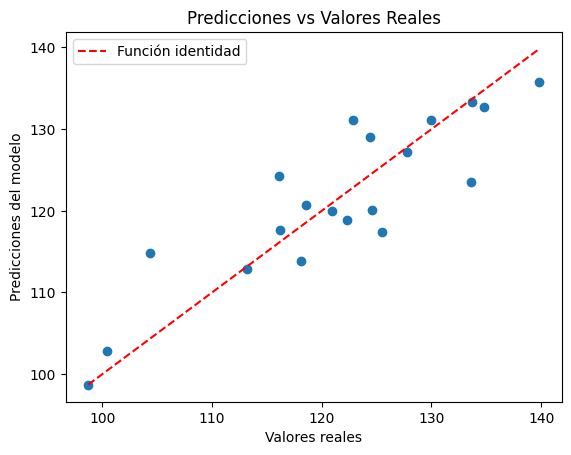

In [22]:
# graficar las predicciones vs los valores reales
plt.scatter(y, y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones del modelo")
plt.title("Predicciones vs Valores Reales")
# agreguemos el gráfico de la función identidad para comparar
plt.plot([min(y), max(y)], [min(y), max(y)], color='red', linestyle='--', label='Función identidad')
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\predicciones_vs_reales.png")
plt.show()



# 17. Aplicación en Administración de Empresas

Variables:

* inversión en marketing
* precio
* número de vendedores



Modelo

$$
ventas = X\beta
$$



Si dos variables están altamente correlacionadas:

el **núcleo de la matriz detecta redundancia**.

Esto ayuda a:

* seleccionar variables
* evitar sobreajuste

---



# 18. Conexión con Deep Learning

Una capa de red neuronal es

$$
y = Wx
$$



Los subespacios asociados explican:

* información útil
* redundancia
* pérdida de dimensión

---



# 19. Actividad para estudiantes

Dataset agrícola.

Variables:

* lluvia
* temperatura
* fertilización
* humedad



Tareas:

1. construir la matriz $X$
2. calcular el rango
3. calcular el núcleo
4. interpretar redundancia de variables

---



# 20. Actividad tipo Stanford

Preguntas conceptuales:

1. ¿Qué significa que un vector esté en el núcleo?
2. ¿Qué representa el espacio columna en un modelo predictivo?
3. ¿Por qué el error es ortogonal al espacio columna?

---



# 21. Conexión con los módulos siguientes

Este módulo prepara para:

**Módulo 7**

Transformaciones lineales.

**Módulo 8**

Bases ortonormales.

**Módulo 10**

PCA y reducción de dimensionalidad.

---



# 22. Idea clave de la clase

En Ciencia de Datos:

$$
Datos = vectores
$$

$$
Modelos = matrices
$$

$$
Predicciones = espacio\ columna
$$

$$
Errores = núcleo\ izquierdo
$$

---
